(5000, 4) (5000, 1)
(1000, 4) (1000, 1)
(1000, 4) (1000, 1)
Max input value is:  0.9999559
Input/output dim: (4, 1)
Training set, test set: (5000, 1000)
... building the model
... training
epoch 1, minibatch 50/50, minibatch_avg_cost 59.564399 validation error 0.974944
epoch 1, minibatch 50/50, test error of best model 0.972520
Epoch:  10 	Best val error:  0.9749438881874084 	current val error:  0.9749438881874084
Epoch:  20 	Best val error:  0.9749438881874084 	current val error:  0.9749438881874084
Epoch:  30 	Best val error:  0.9749438881874084 	current val error:  0.9749438881874084
Epoch:  40 	Best val error:  0.9749438881874084 	current val error:  0.9749438881874084
epoch 50, minibatch 50/50, minibatch_avg_cost 5.852179 validation error 0.120638
epoch 50, minibatch 50/50, test error of best model 0.118683
Epoch:  50 	Best val error:  0.1206381194293499 	current val error:  0.1206381194293499
Epoch:  60 	Best val error:  0.1206381194293499 	current val error:  0.1206381194293499


The code for file mlfg_final.py ran for 0.57m


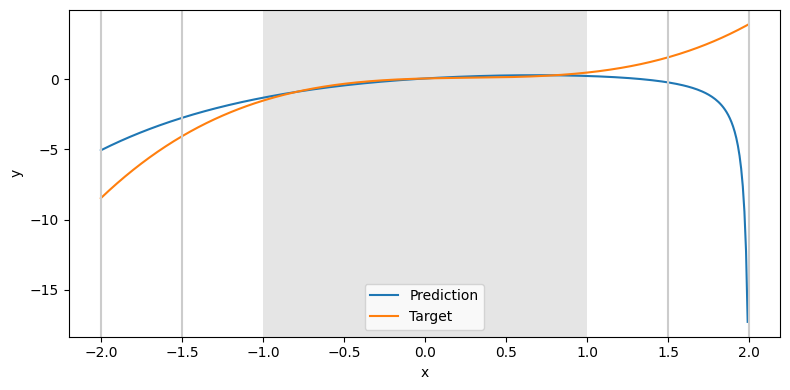

(0.0006704414736*x1**4 + 0.00242951981607*x1**3*x2 + 0.00113094400537*x1**3*x3 - 0.000786184368551*x1**3*x4 + 0.0133236038095*x1**3 + 0.00365312863005*x1**2*x2**2 + 0.00153927337782*x1**2*x2*x3 - 0.00319198045437*x1**2*x2*x4 + 0.0345598976701*x1**2*x2 + 0.000310980943757*x1**2*x3**2 - 0.000640241384983*x1**2*x3*x4 + 0.00605123888957*x1**2*x3 + 0.000444155085018*x1**2*x4**2 + 0.00414380373352*x1**2*x4 - 0.0503661151077*x1**2 + 0.00296975795106*x1*x2**3 + 0.00129400432297*x1*x2**2*x3 - 0.00328179521092*x1*x2**2*x4 + 0.0258646889429*x1*x2**2 + 0.000113823995457*x1*x2*x3**2 - 0.00110407976917*x1*x2*x3*x4 + 0.0226284233519*x1*x2*x3 + 0.00128140128119*x1*x2*x4**2 - 0.0165387033925*x1*x2*x4 - 0.0324465102499*x1*x2 + 0.000217581608868*x1*x3**3 - 0.000502393327729*x1*x3**2*x4 - 0.00148678538848*x1*x3**2 + 0.000335294573512*x1*x3*x4**2 + 0.00571745485231*x1*x3*x4 - 0.0146065026852*x1*x3 - 0.000179012092077*x1*x4**3 - 0.00825325653883*x1*x4**2 + 0.12022855441*x1*x4 + 0.391365414741*x1 + 0.0012617

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.EQLdiv.mlfg_final import test_mlfg


def poly3(x):
    x1, x2, x3, x4 = x
    y = (
        0.7 * x1**3
        - 0.5 * x2**2
        + 0.3 * x3
        + 0.2 * x1 * x4
        - 0.1 * x2 * x3
        + 0.05
    )
    return [y]


def make_dataset(n_train=5000, n_val=1000, n_test=1000, seed=0):
    rng = np.random.RandomState(seed)

    def sample(n):
        X = rng.uniform(-1.0, 1.0, size=(n, 4)).astype(np.float32)
        Y = np.asarray([poly3(x) for x in X], dtype=np.float32)
        return X, Y

    train = sample(n_train)
    val = sample(n_val)
    test = sample(n_test)

    return train, val, test


datasets = make_dataset()

train_x, train_y = datasets[0]
val_x, val_y = datasets[1]
test_x, test_y = datasets[2]

print(train_x.shape, train_y.shape)
print(val_x.shape, val_y.shape)
print(test_x.shape, test_y.shape)

trained = test_mlfg(
    datasets=datasets,
    n_epochs=10000,
    verbose=True,
    learning_rate=0.001,
    basefuncs1=[0],
    basefuncs2=[0],
    L1_reg=1e-3,
    L2_reg=0.0,
    reg_start=200,
    reg_end=800,
    batch_size=100,
    n_layer=2,
    n_per_base=5,
    classifier=None,
    gradient="sgd",
    init_state=None,
    validate_every=50,
    k=50,
)

classifier = trained["classifier"]

print("Best epoch:", trained["best_epoch"])
print("Best val score:", trained["best_val_score"])
print("Num active:", classifier.get_num_active_units())

xs = np.arange(-2, 2, 0.01, dtype=np.float32)
inputs = np.asarray([[x, x, x, 0.1 * x] for x in xs], dtype=np.float32)
targets = np.asarray([poly3(x) for x in inputs], dtype=np.float32)

pred = classifier.evaluate(inputs)

print("MSE on curve:", np.mean((pred[:, 0] - targets[:, 0]) ** 2))

plt.figure(figsize=(8, 4))
plt.plot(xs, pred[:, 0], label="Prediction")
plt.plot(xs, targets[:, 0], label="Target")
plt.axvspan(-1, 1, facecolor="0.8", alpha=0.5)

for extra in [1.5, 2.0]:
    plt.axvline(-extra, c="0.8")
    plt.axvline(extra, c="0.8")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

expr = classifier.get_symbolic_expression(thresh=1e-2, simplify_expr=True)
print(expr)